# Model Comparison

In [1]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

sns.set(style="whitegrid")

In [2]:
results = {

    "Null Model": {
        "Accuracy": 0.4925,
        "Precision": 0.0985,
        "Recall": 0.2000,
        "F1": 0.1320,
        "Balanced Accuracy": 0.2000,
        "Params": 0,
        "Image Size": "N/A",
        "Augmentation": "None",
        "Training Time (min)": 0
    },

    "Logistic Regression": {
        "Accuracy": 0.6317,
        "Precision": 0.4328,
        "Recall": 0.4405,
        "F1": 0.4234,
        "Balanced Accuracy": 0.4405,
        "Params": 11,  # number of features
        "Image Size": "Raw (varies)",
        "Augmentation": "None",
        "Training Time (min)": 0.1
    },

    "SimpleCNN": {
        "Accuracy": 0.7067,
        "Precision": 0.5164,
        "Recall": 0.3958,
        "F1": 0.3638,
        "Balanced Accuracy": 0.3958,
        "Params": 2_121_509,
        "Image Size": "128×128",
        "Augmentation": "None (raw images)",
        "Training Time (min)": 24.9
    },

    "ResNet-50": {
        "Accuracy": 0.7271,
        "Precision": 0.5667,
        "Recall": 0.5938,
        "F1": 0.5659,
        "Balanced Accuracy": 0.5938,
        "Params": 25_557_032,
        "Image Size": "224×224",
        "Augmentation": "CLAHE + CircularCrop + Resize + Rotate + Brightness/Contrast + Blur",
        "Training Time (min)": 57.3
    },

    "DenseNet-121": {
        "Accuracy": 0.7735,
        "Precision": 0.5974,
        "Recall": 0.6041,
        "F1": 0.5932,
        "Balanced Accuracy": 0.6041,
        "Params": 7_978_856,
        "Image Size": "320×320",
        "Augmentation": "CLAHE + CircularCrop + Resize + Rotate + Flip + Brightness/Contrast + Blur",
        "Training Time (min)": 50.5
    }
}

In [3]:
df = pd.DataFrame(results).T
df

,Accuracy,Precision,Recall,F1,Balanced Accuracy,Params,Image Size,Augmentation,Training Time (min)
Null Model,0.4925,0.0985,0.2,0.132,0.2,0,N/A,None,0
Logistic Regression,0.6317,0.4328,0.4405,0.4234,0.4405,11,Raw (varies),None,0.1
SimpleCNN,0.7067,0.5164,0.3958,0.3638,0.3958,2121509,128×128,None (raw images),24.9
ResNet-50,0.7271,0.5667,0.5938,0.5659,0.5938,25557032,224×224,CLAHE + CircularCrop + Resize + Rotate + Brigh...,57.3
DenseNet-121,0.7735,0.5974,0.6041,0.5932,0.6041,7978856,320×320,CLAHE + CircularCrop + Resize + Rotate + Flip ...,50.5


/tmp/ipykernel_3825097/2452752403.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df["Accuracy"], palette="viridis")


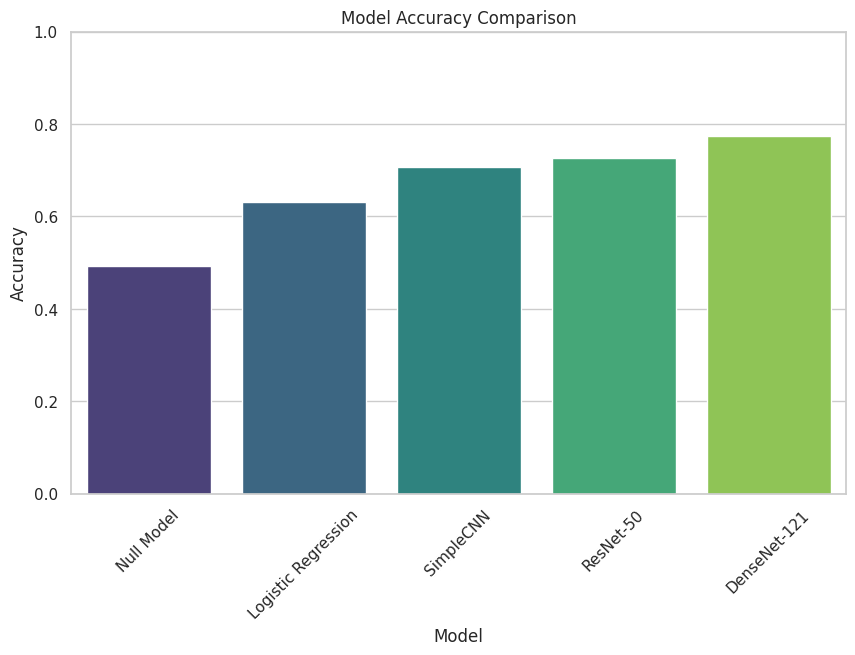

In [4]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.index, y=df["Accuracy"], palette="viridis")
plt.xticks(rotation=45)
plt.title("Model Accuracy Comparison")
plt.ylabel("Accuracy")
plt.xlabel("Model")
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_3825097/1746942619.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df["F1"], palette="magma")


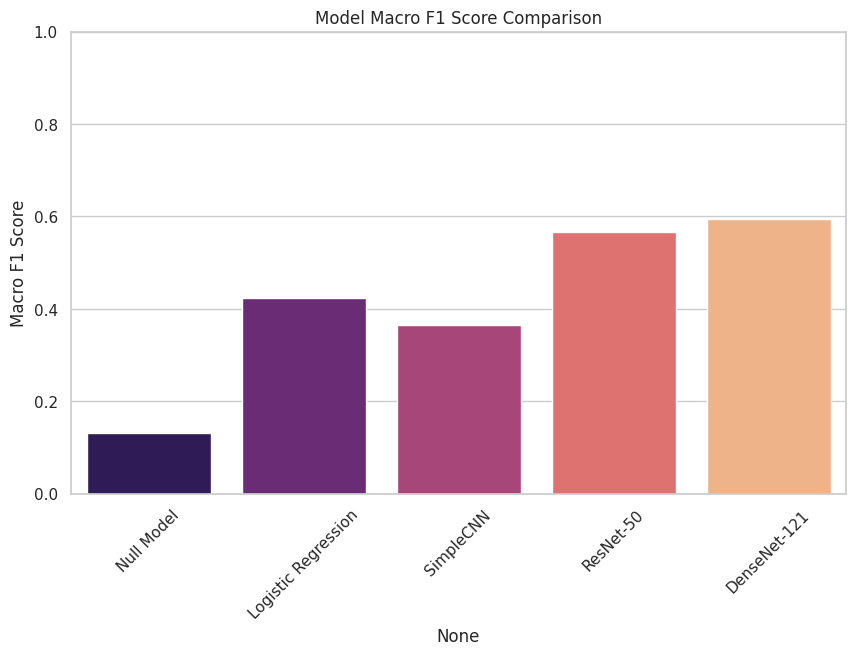

In [5]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.index, y=df["F1"], palette="magma")
plt.xticks(rotation=45)
plt.title("Model Macro F1 Score Comparison")
plt.ylabel("Macro F1 Score")
plt.ylim(0, 1)
plt.show()

/tmp/ipykernel_3160542/1862972643.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df["Params"], palette="crest")


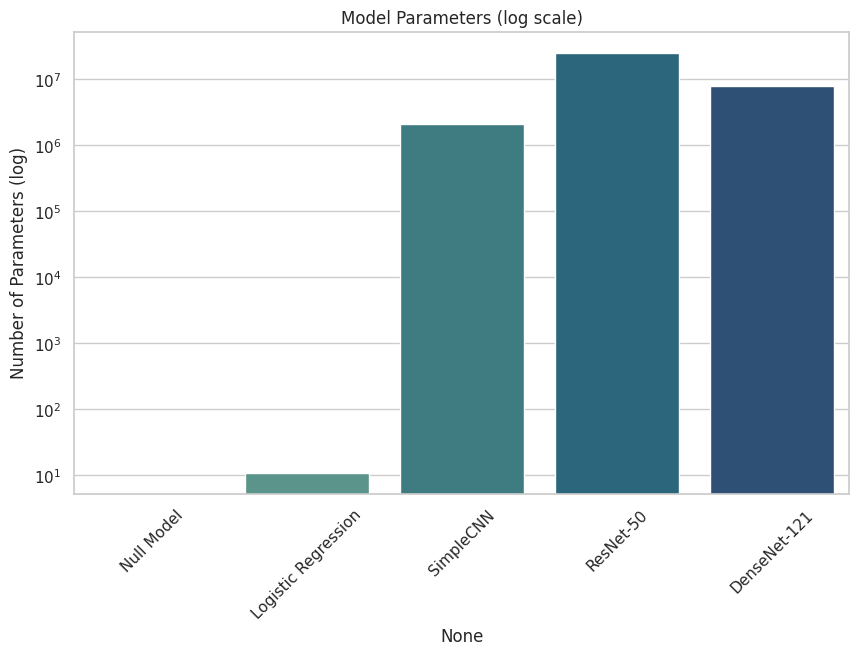

In [9]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.index, y=df["Params"], palette="crest")
plt.yscale("log")
plt.title("Model Parameters (log scale)")
plt.ylabel("Number of Parameters (log)")
plt.xticks(rotation=45)
plt.show()

/tmp/ipykernel_3825097/1557818630.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=df.index, y=df["Training Time (min)"], palette="rocket")


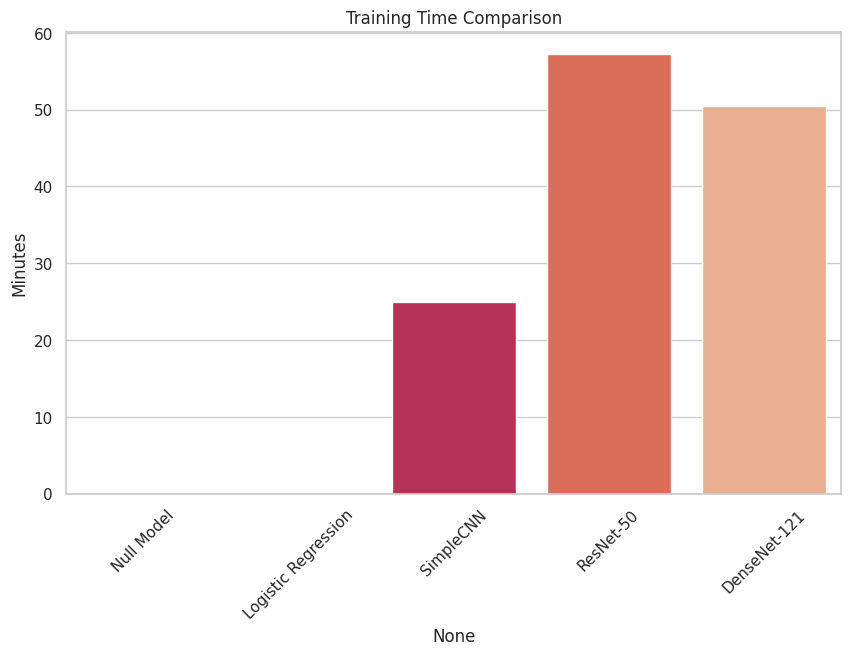

In [6]:
plt.figure(figsize=(10,6))
sns.barplot(x=df.index, y=df["Training Time (min)"], palette="rocket")
plt.xticks(rotation=45)
plt.title("Training Time Comparison")
plt.ylabel("Minutes")
plt.show()

In [7]:
df[["Image Size", "Augmentation", "Params", "Training Time (min)"]]

,Image Size,Augmentation,Params,Training Time (min)
Null Model,N/A,None,0,0
Logistic Regression,Raw (varies),None,11,0.1
SimpleCNN,128×128,None (raw images),2121509,24.9
ResNet-50,224×224,CLAHE + CircularCrop + Resize + Rotate + Brigh...,25557032,57.3
DenseNet-121,320×320,CLAHE + CircularCrop + Resize + Rotate + Flip ...,7978856,50.5


In [8]:
best_model = df["Accuracy"].idxmax()
print(f"Best model based on validation accuracy: **{best_model}**")

Best model based on validation accuracy: **DenseNet-121**


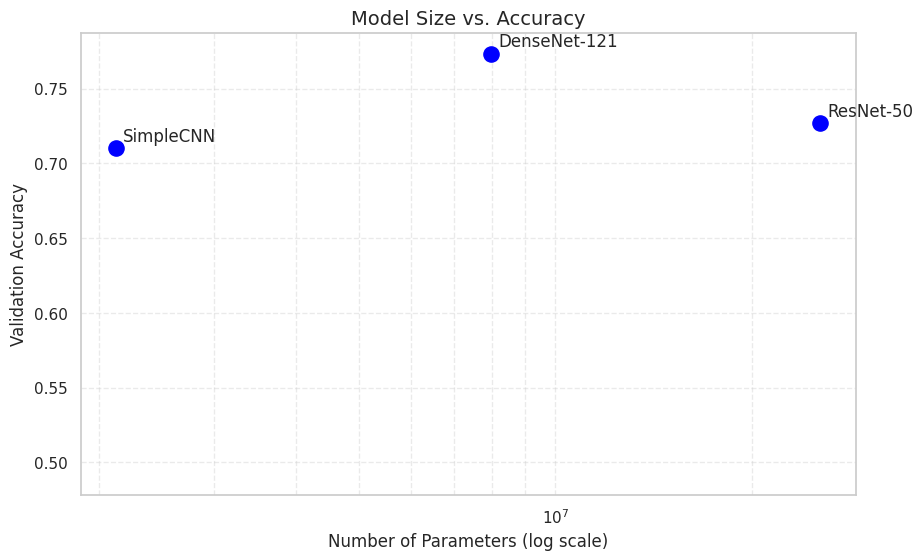

In [9]:
import matplotlib.pyplot as plt

# Hardcoded values from your results
models = ["Null", "Logistic", "SimpleCNN", "ResNet-50", "DenseNet-121"]
params = [0, 0, 2.12e6, 25.5e6, 7.97e6]  # parameter counts
accuracy = [0.4925, 0.6317, 0.71, 0.7271, 0.7735]

plt.figure(figsize=(10,6))
plt.scatter(params, accuracy, s=120, color='blue')

# Annotate each point
for i, m in enumerate(models):
    plt.annotate(m, (params[i], accuracy[i]), textcoords="offset points", xytext=(5,5))

plt.xscale("log")  # log scale makes spread clearer
plt.xlabel("Number of Parameters (log scale)", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.title("Model Size vs. Accuracy", fontsize=14)
plt.grid(True, which="both", linestyle="--", alpha=0.4)

plt.show()

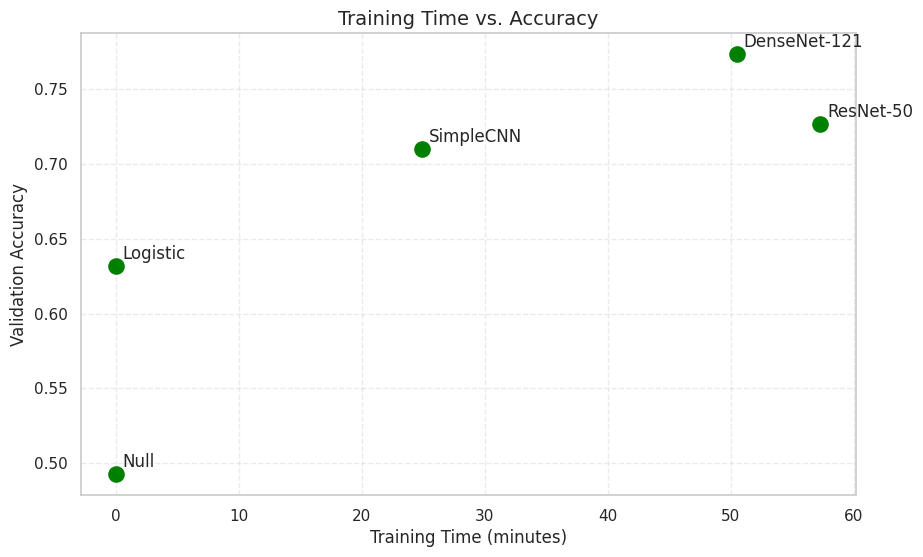

In [10]:
import matplotlib.pyplot as plt

models = ["Null", "Logistic", "SimpleCNN", "ResNet-50", "DenseNet-121"]
training_time = [0.001, 0.001, 24.9, 57.3, 50.5]  # approximate minutes
accuracy = [0.4925, 0.6317, 0.71, 0.7271, 0.7735]

plt.figure(figsize=(10,6))
plt.scatter(training_time, accuracy, s=120, color='green')

# Annotate points
for i, m in enumerate(models):
    plt.annotate(m, (training_time[i], accuracy[i]), textcoords="offset points", xytext=(5,5))

plt.xlabel("Training Time (minutes)", fontsize=12)
plt.ylabel("Validation Accuracy", fontsize=12)
plt.title("Training Time vs. Accuracy", fontsize=14)
plt.grid(True, linestyle="--", alpha=0.4)

plt.show()

In [11]:
import matplotlib.pyplot as plt
import pandas as pd

# Convert results dict → DataFrame
df = pd.DataFrame(results).T[
    ["Precision", "Recall", "Balanced Accuracy"]
]

df

,Precision,Recall,Balanced Accuracy
Null Model,0.0985,0.2,0.2
Logistic Regression,0.4328,0.4405,0.4405
SimpleCNN,0.5164,0.3958,0.3958
ResNet-50,0.5667,0.5938,0.5938
DenseNet-121,0.5974,0.6041,0.6041


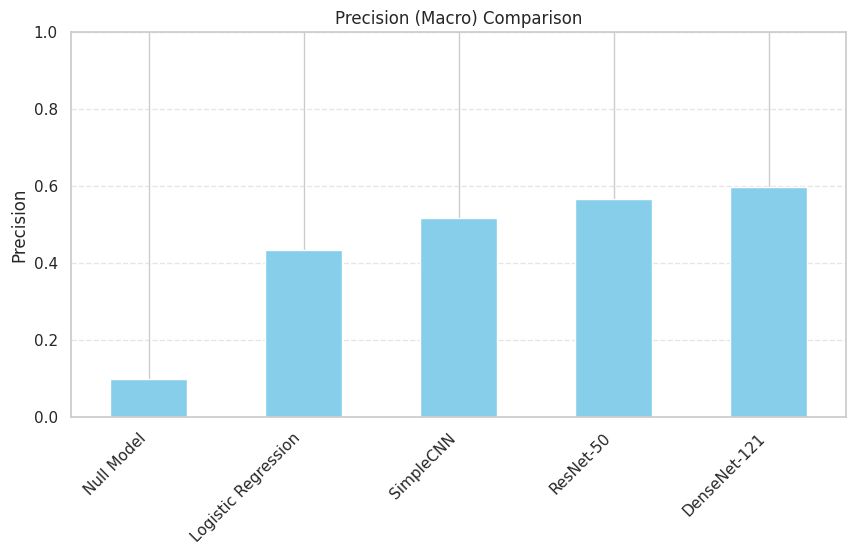

In [12]:
plt.figure(figsize=(10, 5))
df["Precision"].plot(kind="bar", color="skyblue")
plt.title("Precision (Macro) Comparison")
plt.ylabel("Precision")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

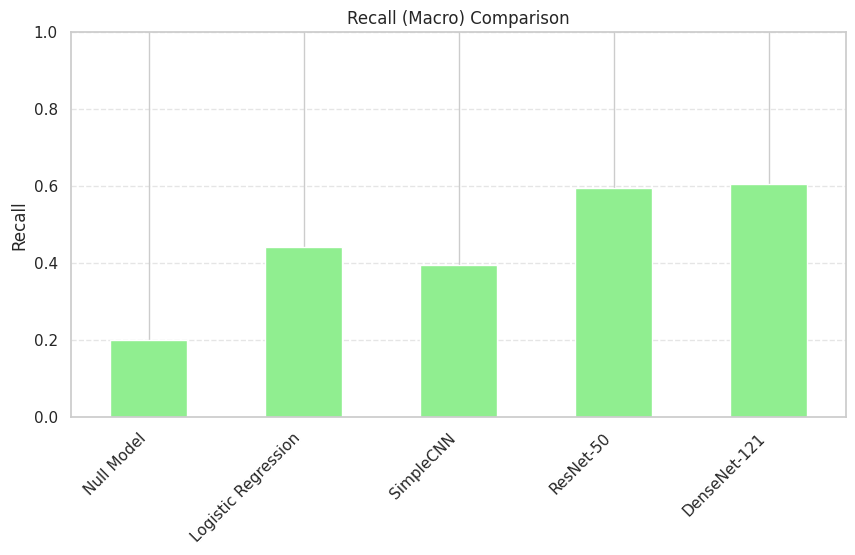

In [14]:
plt.figure(figsize=(10, 5))
df["Recall"].plot(kind="bar", color="lightgreen")
plt.title("Recall (Macro) Comparison")
plt.ylabel("Recall")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

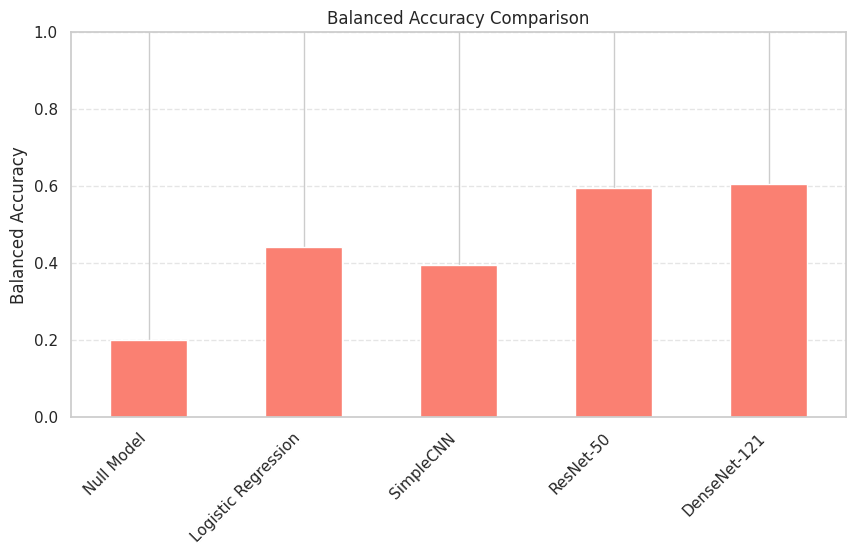

In [15]:
plt.figure(figsize=(10, 5))
df["Balanced Accuracy"].plot(kind="bar", color="salmon")
plt.title("Balanced Accuracy Comparison")
plt.ylabel("Balanced Accuracy")
plt.ylim(0, 1)
plt.xticks(rotation=45, ha='right')
plt.grid(axis='y', linestyle='--', alpha=0.5)
plt.show()

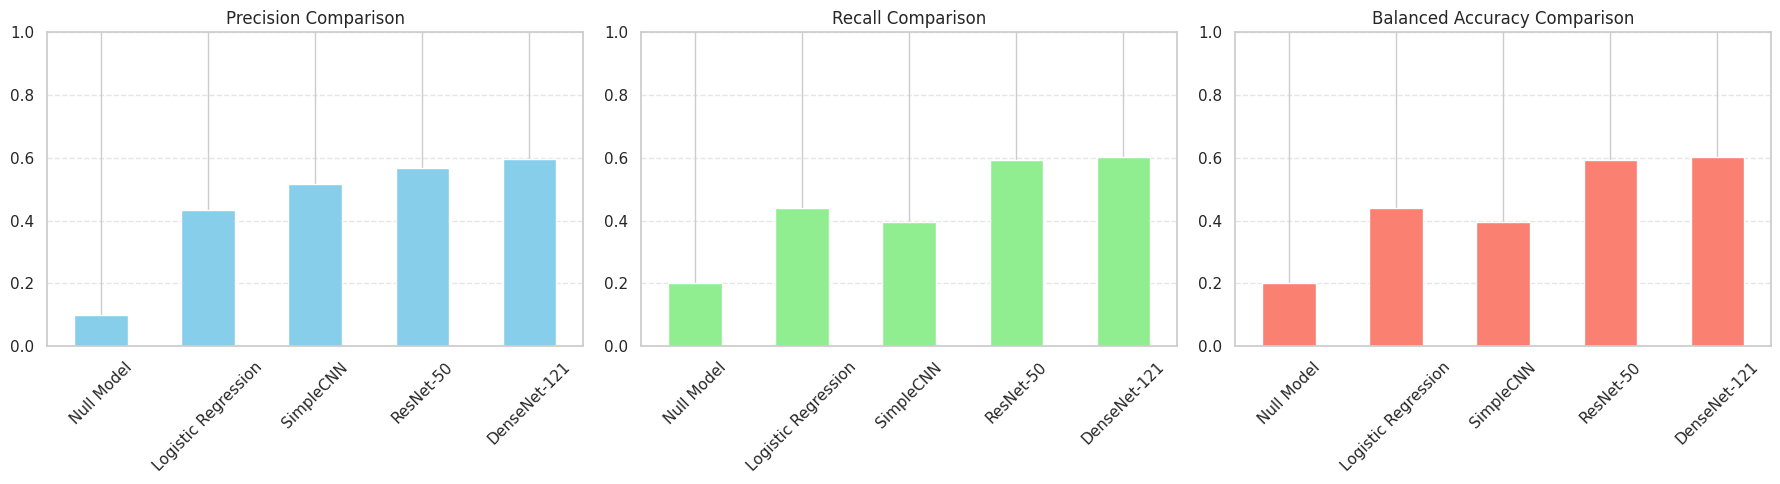

In [16]:
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

metrics = ["Precision", "Recall", "Balanced Accuracy"]
colors = ["skyblue", "lightgreen", "salmon"]

for ax, metric, color in zip(axes, metrics, colors):
    df[metric].plot(kind="bar", ax=ax, color=color)
    ax.set_title(f"{metric} Comparison")
    ax.set_ylim(0, 1)
    ax.grid(axis='y', linestyle='--', alpha=0.5)
    ax.tick_params(axis='x', rotation=45)

plt.tight_layout()
plt.show()